In [1]:
from functions import *
from operator import matmul
import pandas as pd
import numpy as np
from mass_charge_dict import ELEMENTS2Z, Z2ELEMENTS,elements_dict
from scipy import linalg
from scipy.spatial.transform import Rotation as rot_trafo
from math import log10 , floor
import glob as glob
import time as time
from scipy.stats import linregress 
import matplotlib.pyplot as plt
import os
import random as random
from sklearn.ensemble import RandomForestRegressor
from sklearn import svm
from sklearn.model_selection import GridSearchCV
from sklearn.neighbors import KNeighborsRegressor
from sklearn.feature_selection import r_regression

plt.style.use('rwth_colors.mplstyle')

from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import  Matern ,RBF
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GroupShuffleSplit

from ml_functions_permutation import *
from sklearn.ensemble import ExtraTreesRegressor
from sklearn.inspection import permutation_importance
import time as time
from sklearn.metrics import mean_squared_error

from sklearn import preprocessing

In [2]:
mol_list = ['H2','N2','O2','F2','CO','HF','H2O','NH3']
molecules = mol_list
print(modIP)
FT_df,col_name,N_at = gen_X_y_DF(molecules)
FT_df = FT_df.reset_index(drop = True)

perm
Importing Molecule No. 0
tests/H2/H2_0.3/
Generating DataFrame
Importing Molecule No. 1
tests/H2/H2_0.3/
Generating DataFrame
Importing Molecule No. 2
tests/H2/H2_0.3/
Generating DataFrame
Importing Molecule No. 3
tests/H2/H2_0.3/
Generating DataFrame
Importing Molecule No. 4
tests/H2/H2_0.3/
Generating DataFrame
Importing Molecule No. 5
tests/H2/H2_0.3/
Generating DataFrame
Importing Molecule No. 6
tests/H2/H2_0.3/
Generating DataFrame
Importing Molecule No. 7
tests/H2/H2_0.3/
Generating DataFrame


In [3]:
for sm in ['m']:#['m']:
    list_test = []
    list_true = []

    r_score_diag_list = []
    r_score_non_diag_list = []



    x_list = []
    y_list = []
    #Predicted Hessian 
    hess_ML_list = []
    hess_xTB_list = []
    
    #projected Hessian
    hess_p_ML_list = []
    hess_p_xTB_list = []

    #mass weighted Hessian
    hess_w_ML_list = []
    hess_w_xTB_list = []

    #Wavenumbers
    wn_ML_list = []
    wn_xTB_list = []

    #Eigenvalues of the predicted Hessian
    eigv_ML_list = []
    eigv_xTB_list = []

    #Zero-Point-Energy
    ZPE_xTB_list = []
    ZPE_ML_list = []


    mol_list = ['H2','N2','O2','F2','CO','HF','H2O','NH3']
    molecules = mol_list


    MSE_d_list = []
    MSE_nd_list = []
    if sm == 'm':
        rng = 1
    elif sm == 's':
        rng = 8

    for i in range(rng):
    #X_diag_prep, y_diag_prep, X_non_diag_prep, y_non_diag_prep = gen_feature_target_precursor(X_df,y_df)
        if sm == 's':
            FT_df_red = FT_df.loc[FT_df['molecule'] == i]
        elif sm == 'm':
            FT_df_red = FT_df
        
        FT_diag = FT_df_red.loc[FT_df['block'] == 'diag']

        FT_non_diag = FT_df_red.loc[FT_df['block'] == 'nondiag']
        if modIP == 'indexed':
            N_col = 46
        elif modIP == 'perm':
            N_col = 44

        col_name_Features_diag = col_name[8:N_col]

        col_name_Features_ndiag = col_name[8:]

        X_diag = np.array(FT_diag[col_name_Features_diag])

        #randomization
        # X_d_mean  = (X_diag.mean(axis = 0))
        # X_diag = X_diag+ X_d_mean*np.random.rand(len(X_diag),len(X_diag[0])) * rnd_factor

        y_diag = np.array(FT_diag['y'])

        X_non_diag = np.array(FT_non_diag[col_name_Features_ndiag])

        #randomization
        # X_nd_mean  = (X_non_diag.mean(axis = 0))
        # X_non_diag = X_non_diag+ X_nd_mean*np.random.rand(len(X_non_diag),len(X_non_diag[0])) * rnd_factor

        y_non_diag = np.array(FT_non_diag['y'])

        grps_diag,grps_non_diag =  get_grps(FT_diag,FT_non_diag)

        #split_perc = np.arange(0.1,1.01,0.1)


        r_diag = r_regression(X_diag,y_diag)
        r_ndiag = r_regression(X_non_diag,y_non_diag)

        print(r_diag)

        np.savetxt('plots/rdiag',r_diag)
        np.savetxt('plots/rndiag',r_ndiag)


        #############################
        #Separation into Training and Test data
        for rnd_state in []:#[0,22,42,100,63]:#,54,96,35,408,74]:#
            gss = GroupShuffleSplit(n_splits=1,train_size=0.75,random_state = rnd_state)

            idx_diag = list(gss.split(X_diag, y_diag, grps_diag))

            idx_non_diag = list(gss.split(X_non_diag,y_non_diag,grps_non_diag))

            train_idx_tot = idx_diag[0][0]
            test_idx =  idx_diag[0][1]


            train_idx_non_diag_tot = idx_non_diag[0][0]
            test_idx_non_diag =  idx_non_diag[0][1]

            # for i in split_perc:

            #     x_list.append(i)
            #     x = int(len(train_idx_tot)*i)

            #     train_idx = random.sample(list(train_idx_tot),x)

            train_idx = train_idx_tot

            X_train = X_diag[train_idx]
            X_test = X_diag[test_idx]
            
            grps_test = grps_diag[test_idx]


            y_train = y_diag[train_idx]
            y_test = y_diag[test_idx]

                
                # y = int(len(train_idx_non_diag_tot)*i)
                # train_idx_non_diag = random.sample(list(train_idx_non_diag_tot),y)
                
            train_idx_non_diag= train_idx_non_diag_tot

            X_non_diag_train = X_non_diag[train_idx_non_diag]
            X_non_diag_test = X_non_diag[test_idx_non_diag]
            
            grps_test_non_diag = grps_non_diag[test_idx_non_diag]

            y_non_diag_train = y_non_diag[train_idx_non_diag]
            y_non_diag_test = y_non_diag[test_idx_non_diag]

            #############################
            # Training and Prediction via ML
            print('Start Fitting of Machine Learning')

            regr_diag =  ExtraTreesRegressor(n_estimators = 300,random_state=rnd_state,bootstrap=False) 

            #regr_diag = KNeighborsRegressor(n_neighbors= 25 ,weights='distance')
            #regr_diag = GridSearchCV(svm.SVR(),param_grid,cv = 2)

            regr_non_diag = ExtraTreesRegressor(n_estimators = 100,random_state=rnd_state,bootstrap=False)
            
            #regr_non_diag = GridSearchCV(svm.SVR(),param_grid,cv = 2)
            #regr_non_diag = KNeighborsRegressor(n_neighbors= 25 ,weights='distance')

            model_diag = regr_diag.fit(X_train, y_train)

            model_non_diag = regr_non_diag.fit(X_non_diag_train, y_non_diag_train)

            hess_diag_pred = regr_diag.predict(X_test)

            hess_non_diag_pred = regr_non_diag.predict(X_non_diag_test)

            #############################
            #Results and Plots of diagonal hessian matrix blocks
            rscore_diag = regr_diag.score(X_test,y_test)
            print('Score of diag model:',rscore_diag)
            r_score_diag_list.append(rscore_diag)
            MSE_d  = mean_squared_error(hess_diag_pred,y_test)
            MSE_d_list.append(MSE_d)
            #plot_diag_importances(regr_diag,col_name_Features_diag,rnd_state)
            plot_diag_perm_importances(model_diag,X_test,y_test,col_name_Features_diag,rnd_state)

            #############################
            #Training and Prediction via ML

            #############################
            #Results and Plots of prediction of non diagonal hessian matrix blocks

            rscore_non_diag = regr_non_diag.score(X_non_diag_test,y_non_diag_test)
            print('Score of non diag model:',rscore_non_diag)
            r_score_non_diag_list.append(rscore_non_diag)

            MSE_nd  = mean_squared_error(hess_non_diag_pred,y_non_diag_test)
            MSE_nd_list.append(MSE_nd)

                    #plot_non_diag_importances(regr_non_diag,col_name,rnd_state)
            plot_non_diag_perm_importances(model_non_diag,X_non_diag_test,y_non_diag_test,col_name_Features_diag,rnd_state)

                    #############################
                    #Transformation of the hessian blocks into a full hessian to compute the frequencies
                    #rnd = random.randint(0,len(test_idx)-1)


            # np.savetxt(f'plots/MSE_d_{modIP}_{sm}_RFR',MSE_d_list)
            # np.savetxt(f'plots/MSE_nd_{modIP}_{sm}_RFR',MSE_nd_list)

            np.savetxt('plots/freq_ML',list_test)
            np.savetxt('plots/freq_xTB',list_true)

            np.savetxt('plots/rscore_diag',r_score_diag_list)
            np.savetxt('plots/rscore_nondiag',r_score_non_diag_list)
           
            
            for idx in range(len(np.unique(grps_test))):

                id_0 = np.unique(grps_test)[idx]
                
                temp = (FT_diag.loc[(FT_diag['mol_idx'] == id_0)])

                mol = int(temp['molecule'].iloc[0])

                file_num = int(temp['variation'].iloc[0])

                N_atoms = N_at.iloc[mol]
                
                N_diag = int(N_atoms)

                N_non_diag = int((N_atoms ** 2 - N_atoms)/2)

                id = id_0*N_diag

                ##########

                k = int(np.where(grps_test == id_0)[0][0])

                l = int(np.where(grps_test_non_diag == id_0)[0][0])
                
                num_hess_diag = N_diag * 9
                
                num_hess_non_diag = N_non_diag * 9

                ##########
                
                file_path = glob.glob(f'tests/{molecules[mol]}/{molecules[mol]}_*/')
                inert_path_coord = f'{file_path[file_num]}'+'/inert_coord/coord.xyz'
                inert_path_hess = f'{file_path[file_num]}'+'/inert_coord/hessian'

                rot_arr = gen_rot_arr(file_path[file_num])
                coord_inert,head = import_coord(inert_path_coord)


                #Data of the hessian of the xTB
                hess_inert =  np.array(pd.read_csv(inert_path_hess,delimiter = '\t',index_col = 0))
                hess_xTB_list.extend([item for sublist in hess_inert.tolist() for item in sublist])

                hess_inert_proj,Q = project_hess(hess_inert,coord_inert)
                hess_p_xTB_list.extend([item for sublist in hess_inert_proj.tolist() for item in sublist])

                hess_inert_proj_mass = mass_weighted_hessian(hess_inert_proj.copy(),coord_inert['atoms'])
                hess_w_xTB_list.extend([item for sublist in hess_inert_proj_mass.tolist() for item in sublist])

                eigv_xTB,Q = linalg.eigh(hess_inert)
                eigv_xTB_list.extend(eigv_xTB)
                
                lamb_xTB,Q_xTB = linalg.eigh(hess_inert_proj_mass)
                freq_xTB = frequency(lamb_xTB)

                wn_inert_proj_mass = wavenumber(lamb_xTB)
                wn_true = (wn_inert_proj_mass)
                wn_true.sort()
                wn_xTB_list.extend(wn_true)

                fc_xTB = force_constant(lamb_xTB,coord_inert['atoms'])

                ZPE_xTB_list.extend([sum(freq_xTB)])

                #Data of the hessian of the ML
                # if modIP == 'indexed':
                #     hess_d_p = hess_diag_pred[k:k+num_hess_diag]
                #     hess_nd_p = hess_non_diag_pred[l:l+num_hess_non_diag]

                #     for i in range(len(hess_d_p)//9):
                #         hess_d_p[9*i+3] = -hess_d_p[9*i+3]
                #         hess_d_p[9*i+7] = -hess_d_p[9*i+7]

                #     for i in range(len(hess_nd_p)//9):
                #         hess_nd_p[9*i+3]= -hess_nd_p[9*i+3]
                #         hess_nd_p[9*i+7] = -hess_nd_p[9*i+7]

                # elif modIP == 'perm':
                hess_d_p = hess_diag_pred[k:k+num_hess_diag]
                hess_nd_p = hess_non_diag_pred[l:l+num_hess_non_diag]

                    
                hess = gen_full_hess_mat_from_vector(FT_df,hess_d_p,hess_nd_p,N_atoms,mol,file_num,rot_arr)
            
                hess_ML_list.extend([item for sublist in hess.tolist() for item in sublist])

                hess_proj,Q= project_hess(hess,coord_inert)
                hess_p_ML_list.extend([item for sublist in hess_proj.tolist() for item in sublist])

                hess_proj_mass = mass_weighted_hessian(hess_proj.copy(),coord_inert['atoms'])
                hess_w_ML_list.extend([item for sublist in hess_proj_mass.tolist() for item in sublist])

                lamb_ML,Q_ML = linalg.eigh(hess_proj_mass)


                freq_ML = frequency(lamb_ML)

                eigv_ML,Q = linalg.eigh(hess)
                eigv_ML_list.extend(eigv_ML)

                wn_proj_mass = wavenumber(lamb_ML)
                wn_test = (wn_proj_mass)
                wn_test.sort()
                wn_ML_list.extend(wn_test)

                fc_ML = force_constant(lamb_ML,coord_inert['atoms'])

                ZPE_ML_list.extend([sum(freq_ML)])


                if len(wn_inert_proj_mass) != len(wn_proj_mass):
                    print('Error freq not same length')



            np.savetxt(f'plots/MSE_d_{modIP}_{sm}_{rnd_state}',MSE_d_list)
            np.savetxt(f'plots/MSE_nd_{modIP}_{sm}_{rnd_state}',MSE_nd_list)

            np.savetxt(f'plots/MSE_d_{modIP}_{sm}_{rnd_state}',MSE_d_list)
            np.savetxt(f'plots/MSE_nd_{modIP}_{sm}_{rnd_state}',MSE_nd_list)
        
    np.savetxt(f'plots/hess_ML_{modIP}_{sm}',hess_ML_list)
    np.savetxt(f'plots/hess_xTB_{modIP}_{sm}',hess_xTB_list)

    np.savetxt(f'plots/hess_w_ML_{modIP}_{sm}',hess_w_ML_list)
    np.savetxt(f'plots/hess_w_xTB_{modIP}_{sm}',hess_w_xTB_list)

    np.savetxt(f'plots/ZPE_ML_{modIP}_{sm}',ZPE_ML_list)
    np.savetxt(f'plots/ZPE_xTB_{modIP}_{sm}',ZPE_xTB_list)

    np.savetxt(f'plots/wn_ML_{modIP}_{sm}',wn_ML_list)
    np.savetxt(f'plots/wn_xTB_{modIP}_{sm}',wn_xTB_list)

    np.savetxt(f'plots/hess_p_ML_{modIP}_{sm}',hess_p_ML_list)
    np.savetxt(f'plots/hess_p_xTB_{modIP}_{sm}',hess_p_xTB_list)

    np.savetxt(f'plots/eigv_ML_{modIP}_{sm}',eigv_ML_list)
    np.savetxt(f'plots/eigv_xTB_{modIP}_{sm}',eigv_xTB_list)


[-0.09661156         nan  0.13272929  0.11795928 -0.18599779  0.07051043
  0.01079177  0.0334363   0.08724821 -0.02255561 -0.00133337  0.05347859
 -0.00251276  0.0267879   0.03539246  0.00131641 -0.14885706  0.02673467
  0.08472035 -0.05799206  0.03460602  0.23194568  0.03210282  0.08009791
  0.3000082   0.01994333 -0.00408772         nan  0.00799069  0.04989553
  0.02896863 -0.03555981  0.22073303  0.12561184 -0.05505968  0.16208424]


/home/gfeldmann/Venv/venv_hessian_ml/lib/python3.8/site-packages/sklearn/feature_selection/_univariate_selection.py:289: RuntimeWarning: invalid value encountered in true_divide
  correlation_coefficient /= X_norms
/home/gfeldmann/Venv/venv_hessian_ml/lib/python3.8/site-packages/sklearn/feature_selection/_univariate_selection.py:289: RuntimeWarning: invalid value encountered in true_divide
  correlation_coefficient /= X_norms


findfont: Font family ['sans-serif'] not found. Falling back to DejaVu Sans.
findfont: Generic family 'sans-serif' not found because none of the following families were found: Fira Sans


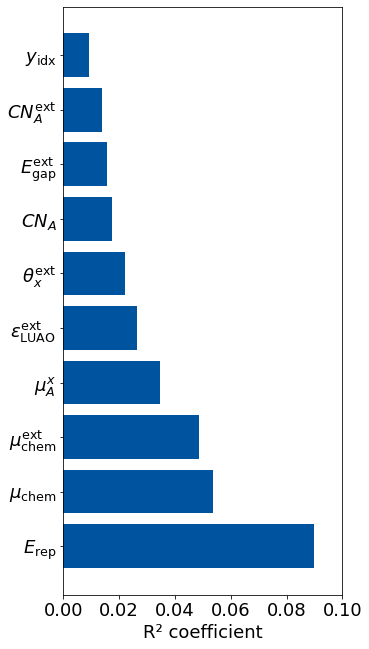

In [5]:
col_name =  [r'$y_\mathrm{idx}$', r'$R_{AB}$', r'$CN_A$', r'$CN_A^\mathrm{ext}$', r'$\mu_A^x$', r'$\mu_A^y$', r'$\mu_A^z$', r'$\mu_A^{x,\mathrm{ext}}$', r'$\mu_A^{y,\mathrm{ext}}$', r'$\mu_A^{z,\mathrm{ext}}$',
r'$\mu_{A,p}^{x,\mathrm{ext}}$', r'$\mu_{A,p}^{y,\mathrm{ext}}$', r'$\mu_{A,p}^{z,\mathrm{ext}}$',
r'$\theta_x$', r'$\theta_y$', r'$\theta_z$', r'$\theta_x^\mathrm{ext}$', r'$\theta_y^\mathrm{ext}$', r'$\theta_z^\mathrm{ext}$',
r'$E_\mathrm{resp}$', r'$E_\mathrm{gap}$', r'$\mu_\mathrm{chem}$', r'$\epsilon_\mathrm{HOAO}$', r'$\epsilon_\mathrm{LUAO}$', r'$E_\mathrm{rep}$', r'$E_\mathrm{EHT}$',
r'$E_\mathrm{disp}^{(2)}$', r'$E_\mathrm{disp}^{(3)}$', r'$E_\mathrm{IES+IXC}$', r'$E_\mathrm{AES}$',
 r'$E_\mathrm{tot}$', r'$E_\mathrm{AXC}$', r'$\mu_\mathrm{chem}^\mathrm{ext}$', r'$E_\mathrm{gap}^\mathrm{ext}$', r'$\epsilon_\mathrm{HOAO}^\mathrm{ext}$', r'$\epsilon_\mathrm{LUAO}^\mathrm{ext}$']

plt.style.use('rwth_colors.mplstyle')
r_diag_10 = []
col_name_10 = []

r2_diag_find = r_diag.copy()**2
for i in range(10):
    idx = np.nanargmax(r2_diag_find)
    r_diag_10.append(r2_diag_find[idx])
    col_name_10.append(col_name[idx])
    r2_diag_find[idx] -= r2_diag_find[idx]

ticks_d  =[0,1,2,3,4,5,6,7,8,9]

fig,ax = plt.subplots()
ax.barh(ticks_d,r_diag_10)
ax.set_yticks(ticks_d)
ax.set_yticklabels(col_name_10)

fig.set_figheight(19)
fig.set_figwidth(5)

plt.gcf().subplots_adjust(bottom=0.45)
plt.xlim([0,0.1])

ax.set_xlabel('R² coefficient')
save_name = 'Bericht/PearsonCorrelationCoeffiecient/PCC_diag_perm'

plt.savefig(f'{save_name}.svg')
plt.savefig(f'{save_name}.eps')
plt.savefig(f'{save_name}.png')

[72, 58, 38, 0, 16, 24, 62, 50, 89, 21]


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


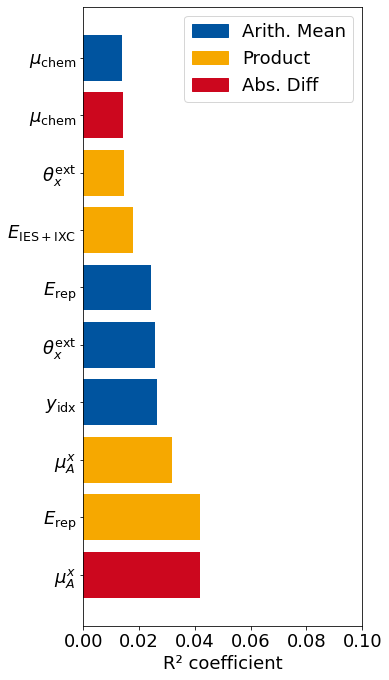

In [7]:
import matplotlib.patches as mpatches
import matplotlib.colors

color_map = matplotlib.colors.get_named_colors_mapping()
color_map["blue"] = "#00549F"
color_map["red"] = "#F6A800"
color_map["yellow"] = "#CC071E"

col_name_nd = [r'$y_\mathrm{idx}$', r'$R_{AB}$', r'$CN_A$', r'$CN_A^\mathrm{ext}$', r'$\mu_A^x$', r'$\mu_A^y$', r'$\mu_A^z$', r'$\mu_A^{x,\mathrm{ext}}$', r'$\mu_A^{y,\mathrm{ext}}$', r'$\mu_A^{z,\mathrm{ext}}$',
r'$\mu_{A,p}^{x,\mathrm{ext}}$', r'$\mu_{A,p}^{y,\mathrm{ext}}$', r'$\mu_{A,p}^{z,\mathrm{ext}}$',
r'$\theta_x$', r'$\theta_y$', r'$\theta_z$', r'$\theta_x^\mathrm{ext}$', r'$\theta_y^\mathrm{ext}$', r'$\theta_z^\mathrm{ext}$',
r'$E_\mathrm{resp}$', r'$E_\mathrm{gap}$', r'$\mu_\mathrm{chem}$', r'$\epsilon_\mathrm{HOAO}$', r'$\epsilon_\mathrm{LUAO}$', r'$E_\mathrm{rep}$', r'$E_\mathrm{EHT}$',
r'$E_\mathrm{disp}^{(2)}$', r'$E_\mathrm{disp}^{(3)}$', r'$E_\mathrm{IES+IXC}$', r'$E_\mathrm{AES}$',
 r'$E_\mathrm{tot}$', r'$E_\mathrm{AXC}$', r'$\mu_\mathrm{chem}^\mathrm{ext}$', r'$E_\mathrm{gap}^\mathrm{ext}$', r'$\epsilon_\mathrm{HOAO}^\mathrm{ext}$', r'$\epsilon_\mathrm{LUAO}^\mathrm{ext}$']

#r'$x_i$', r'$y_i$', r'$z_i$'
r_ndiag_10 = []
col_name_10 = []
idx_list = []

r2_ndiag_find = r_ndiag.copy()**2
for i in range(10):
    idx = np.nanargmax(r2_ndiag_find)
    idx_list.append(idx)
    r_ndiag_10.append(r2_ndiag_find[idx])
    #col_name_10.append(col_name_nd[idx])
    r2_ndiag_find[idx] -= r2_ndiag_find[idx]
print(idx_list)

list_list = []

for i in range(len(idx_list)):
    if idx_list[i]>len(col_name_nd) and idx_list[i]<2*len(col_name_nd)-2:
        idx_list[i] = idx_list[i]- (len(col_name_nd)-2)
        list_list.append(1)

    elif idx_list[i]>2*len(col_name_nd)-4 and idx_list[i]<3*len(col_name_nd)-2:
        idx_list[i] = idx_list[i]- 2*(len(col_name_nd)-2)
        list_list.append(2)

    else:
        list_list.append(0)

for i in range(10):
    col_name_10.append(col_name_nd[idx_list[i]])

ticks_nd  = [0,1,2,3,4,5,6,7,8,9]

fig,ax = plt.subplots()
color = ['blue','red','yellow']

for i in range(len(r_ndiag_10)):
    ax.barh(ticks_nd[i],r_ndiag_10[i],color=color[list_list[i]])
    
ax.set_yticks(ticks_nd)
ax.set_yticklabels(col_name_10)

blue_patch = mpatches.Patch(color='blue', label='Arith. Mean')
green_patch = mpatches.Patch(color='red', label='Product')
orange_patch = mpatches.Patch(color='yellow', label='Abs. Diff')

ax.legend(handles=[blue_patch,green_patch,orange_patch])

fig.set_figheight(20)
fig.set_figwidth(5)
plt.gcf().subplots_adjust(bottom=0.45)
plt.xlim([0,0.1])

ax.set_xlabel('R² coefficient')

save_name = 'Bericht/PearsonCorrelationCoeffiecient/PCC_ndiag_perm'
plt.savefig(f'{save_name}.svg')
plt.savefig(f'{save_name}.eps')
plt.savefig(f'{save_name}.png')

In [2]:
mol_list = ['H2','N2','O2','F2','CO','HF','H2O','NH3','H3']
molecules = mol_list

FT_df,col_name,N_at = gen_X_y_DF(molecules)
FT_df = FT_df.reset_index(drop = True)

Importing Molecule No. 0
tests/H2/H2_0.3/
Generating DataFrame
Importing Molecule No. 1
tests/H2/H2_0.3/
Generating DataFrame
Importing Molecule No. 2
tests/H2/H2_0.3/
Generating DataFrame
Importing Molecule No. 3
tests/H2/H2_0.3/
Generating DataFrame
Importing Molecule No. 4
tests/H2/H2_0.3/
Generating DataFrame
Importing Molecule No. 5
tests/H2/H2_0.3/
Generating DataFrame
Importing Molecule No. 6
tests/H2/H2_0.3/
Generating DataFrame
Importing Molecule No. 7
tests/H2/H2_0.3/
Generating DataFrame
Importing Molecule No. 8
tests/H2/H2_0.3/
Generating DataFrame


In [ ]:
FT_p1 = FT_df.loc[(FT_df['variation'] == 2) & (FT_df['molecule'] == 8)& (FT_df['atom1'] == 0) & (FT_df['atom2'] == 1)  & (FT_df['block'] == 'nondiag')] 
FT_p2 = FT_df.loc[(FT_df['variation'] == 7) & (FT_df['molecule'] == 8)& (FT_df['atom1'] == 1) & (FT_df['atom2'] == 2) & (FT_df['block'] == 'nondiag')] 

# FT_p1.iloc[:,10:30].to_csv('plots/FT_p1')
# FT_p2.iloc[:,10:30].to_csv('plots/FT_p2')

p1 = (FT_p1.iloc[:,7:79])
p2 = (FT_p2.iloc[:,7:79])
print(p1)
print(p2)
p1.to_csv('plots/p11')
p2.to_csv('plots/p21')

In [3]:
list_test = []
list_true = []

r_score_diag_list = []
r_score_non_diag_list = []

MSE_d_list = []
MSE_nd_list = []

x_list = []
y_list = []
#Predicted Hessian 
hess_ML_list = []
hess_xTB_list = []

#projected Hessian
hess_p_ML_list = []
hess_p_xTB_list = []

#mass weighted Hessian
hess_w_ML_list = []
hess_w_xTB_list = []

#Wavenumbers
wn_ML_list = []
wn_xTB_list = []

#Eigenvalues of the predicted Hessian
eigv_ML_list = []
eigv_xTB_list = []

#Zero-Point-Energy
ZPE_xTB_list = []
ZPE_ML_list = []

#force constant 
fc_ML_list = []
fc_xTB_list = []

#(non) - Diagonal elements 
hess_nd_list = []
hess_d_list = []

mol_list = ['H2','N2','O2','F2','CO','HF','H2O','NH3','H3']
molecules = mol_list

sm = 'm'

if sm == 'm':
    rng = 1
elif sm == 's':
    rng = 8

for i in range(rng): #rnd_factor[0.0,0.5,1,1.5,2,2.5]:
#X_diag_prep, y_diag_prep, X_non_diag_prep, y_non_diag_prep = gen_feature_target_precursor(X_df,y_df)
    if sm == 's':
        FT_df_red = FT_df.loc[FT_df['molecule'] == i]
    elif sm == 'm':
        FT_df_red = FT_df
    
    FT_diag = FT_df_red.loc[FT_df['block'] == 'diag']

    FT_non_diag = FT_df_red.loc[FT_df['block'] == 'nondiag']

    if modIP == 'indexed':
        N_col = 46
    elif modIP == 'perm':
        N_col = 44

    col_name_Features_diag = col_name[8:N_col]

    col_name_Features_ndiag = col_name[8:]

    print(col_name_Features_diag)

    FT_diag_train = FT_df_red.loc[(FT_df['block'] == 'diag') & (FT_df['molecule'] != 8)]
    FT_diag_train.reset_index()

    FT_non_diag_train = FT_df_red.loc[(FT_df['block'] == 'nondiag') & (FT_df['molecule'] != 8)]
    FT_non_diag_train.reset_index()

    FT_diag_test = FT_df_red.loc[(FT_df['block'] == 'diag') & (FT_df['molecule'] == 8)]
    FT_diag_test.reset_index()

    FT_non_diag_test = FT_df_red.loc[(FT_df['block'] == 'nondiag') & (FT_df['molecule'] == 8)]
    FT_non_diag_test.reset_index()

    FT_non_diag_test.to_csv('plots/Feature_heteronuc.csv')

    mol_idx_test = np.unique(np.array(FT_diag_test['mol_idx']))

    X_train = np.array(FT_diag_train[col_name_Features_diag])
    X_test = np.array(FT_diag_test[col_name_Features_diag])

    y_train = np.array(FT_diag_train['y'])
    y_test = np.array(FT_diag_test['y'])

    X_non_diag_train = np.array(FT_non_diag_train[col_name_Features_ndiag])
    X_non_diag_test = np.array(FT_non_diag_test[col_name_Features_ndiag])

    y_non_diag_train = np.array(FT_non_diag_train['y'])
    y_non_diag_test = np.array(FT_non_diag_test['y'])

    #############################
    #Separation into Training and Test data
    for rnd_state in [0,22,42,100,63]:#,[54,96,35,408,74]:#
        #############################
        # Training and Prediction via ML
        print('Start Fitting of Machine Learning')

        regr_diag =  ExtraTreesRegressor(n_estimators = 300,random_state=rnd_state,bootstrap=False) 

        #regr_diag = KNeighborsRegressor(n_neighbors= 25 ,weights='distance')
        #regr_diag = GridSearchCV(svm.SVR(),param_grid,cv = 2)

        regr_non_diag = ExtraTreesRegressor(n_estimators = 100,random_state=rnd_state,bootstrap=False)
        
        #regr_non_diag = GridSearchCV(svm.SVR(),param_grid,cv = 2)
        #regr_non_diag = KNeighborsRegressor(n_neighbors= 25 ,weights='distance')

        model_diag = regr_diag.fit(X_train, y_train)

        model_non_diag = regr_non_diag.fit(X_non_diag_train, y_non_diag_train)

        hess_diag_pred = regr_diag.predict(X_test)

        hess_non_diag_pred = regr_non_diag.predict(X_non_diag_test)

        #############################
        #Results and Plots of diagonal hessian matrix blocks
        rscore_diag = regr_diag.score(X_test,y_test)
        print('Score of diag model:',rscore_diag)
        r_score_diag_list.append(rscore_diag)
        MSE_d  = mean_squared_error(hess_diag_pred,y_test)
        MSE_d_list.append(MSE_d)
        #plot_diag_importances(regr_diag,col_name,rnd_state)
        #plot_diag_perm_importances(model_diag,X_test,y_test,col_name_Features_diag,rnd_state)

        #############################
        #Training and Prediction via ML

        #############################
        #Results and Plots of prediction of non diagonal hessian matrix blocks

        rscore_non_diag = regr_non_diag.score(X_non_diag_test,y_non_diag_test)
        print('Score of non diag model:',rscore_non_diag)
        r_score_non_diag_list.append(rscore_non_diag)

        MSE_nd  = mean_squared_error(hess_non_diag_pred,y_non_diag_test)
        MSE_nd_list.append(MSE_nd)

            #plot_non_diag_importances(regr_non_diag,col_name,rnd_state)
        #plot_non_diag_perm_importances(model_non_diag,X_non_diag_test,y_non_diag_test,col_name_Features_diag,rnd_state)

            #############################
            #Transformation of the hessian blocks into a full hessian to compute the frequencies
            #rnd = random.randint(0,len(test_idx)-1)


        """
        np.savetxt('plots/freq_ML',list_test)
        np.savetxt('plots/freq_xTB',list_true)

        np.savetxt('plots/rscore_diag',r_score_diag_list)
        np.savetxt('plots/rscore_nondiag',r_score_non_diag_list)
        """
        print(mol_idx_test)
        k = 0
        l = 0
        print(f'Diag:{len(y_non_diag_test)} NonDiag:{len(y_test)}')
        for id_0 in mol_idx_test:
           
            temp = (FT_diag.loc[(FT_diag['mol_idx'] == id_0)])

            mol = int(temp['molecule'].iloc[0])

            file_num = int(temp['variation'].iloc[0])

            N_atoms = N_at.iloc[mol]
            
            N_diag = int(N_atoms)

            N_non_diag = int((N_atoms ** 2 - N_atoms)/2)

            id = id_0*N_diag

            ##########
           
            num_hess_diag = N_diag * 9
            
            num_hess_non_diag = N_non_diag * 9

            ##########
            
            file_path = sorted(glob.glob(f'tests/{molecules[mol]}/{molecules[mol]}_*/'))
            inert_path_coord = f'{file_path[file_num]}'+'/inert_coord/coord.xyz'
            inert_path_hess = f'{file_path[file_num]}'+'/inert_coord/hessian'

            rot_arr = gen_rot_arr(file_path[file_num])
            coord_inert,head = import_coord(inert_path_coord)


            #Data of the hessian of the xTB
            hess_inert =  np.array(pd.read_csv(inert_path_hess,delimiter = '\t',index_col = 0))
            hess_xTB_list.extend([item for sublist in hess_inert.tolist() for item in sublist])

            hess_inert_proj,Q = project_hess(hess_inert,coord_inert)
            hess_p_xTB_list.extend([item for sublist in hess_inert_proj.tolist() for item in sublist])

            hess_inert_proj_mass = mass_weighted_hessian(hess_inert_proj.copy(),coord_inert['atoms'])
            hess_w_xTB_list.extend([item for sublist in hess_inert_proj_mass.tolist() for item in sublist])

            eigv_xTB,Q = linalg.eigh(hess_inert)
            eigv_xTB_list.extend(eigv_xTB)
            
            lamb_xTB,Q_xTB = linalg.eigh(hess_inert_proj_mass)
            freq_xTB = frequency(lamb_xTB)

            wn_inert_proj_mass = wavenumber(lamb_xTB)
            wn_true = (wn_inert_proj_mass)
            wn_true.sort()
            wn_xTB_list.extend(wn_true)

            fc_xTB = force_constant(lamb_xTB,coord_inert['atoms'])
            fc_xTB_list.extend(fc_xTB)

            ZPE_xTB_list.extend([sum(freq_xTB)])

            # if modIP == 'indexed':
            #     hess_d_p = hess_diag_pred[k:k+num_hess_diag]
            #     hess_nd_p = hess_non_diag_pred[l:l+num_hess_non_diag]

            #     for i in range(len(hess_d_p)//9):
            #         hess_d_p[9*i+3] = -hess_d_p[9*i+3]
            #         hess_d_p[9*i+7] = -hess_d_p[9*i+7]

            #     for i in range(len(hess_nd_p)//9):
            #         hess_nd_p[9*i+3]= -hess_nd_p[9*i+3]
            #         hess_nd_p[9*i+7] = -hess_nd_p[9*i+7]

            # elif modIP == 'perm':
            hess_d_p = hess_diag_pred[k:k+num_hess_diag]
            hess_nd_p = hess_non_diag_pred[l:l+num_hess_non_diag]

            hess_d_list.extend(hess_d_p)
            hess_nd_list.extend(hess_nd_p)

            
            #Data of the hessian of the ML
            hess = gen_full_hess_mat_from_vector(FT_df,hess_d_p,hess_nd_p,N_atoms,mol,file_num,rot_arr)
            
            # if file_num == 2:
            #     np.savetxt(f'plots/hess_d_p1',hess_nd_p[0:9])
            
            # if file_num == 7:
            #     np.savetxt(f'plots/hess_d_p2',hess_nd_p[18:27])

            k += num_hess_diag
            l += num_hess_non_diag

            hess_ML_list.extend([item for sublist in hess.tolist() for item in sublist])

            hess_proj,Q= project_hess(hess,coord_inert)
            hess_p_ML_list.extend([item for sublist in hess_proj.tolist() for item in sublist])

            hess_proj_mass = mass_weighted_hessian(hess_proj.copy(),coord_inert['atoms'])
            hess_w_ML_list.extend([item for sublist in hess_proj_mass.tolist() for item in sublist])

            lamb_ML,Q_ML = linalg.eigh(hess_proj_mass)

            freq_ML = frequency(lamb_ML)

            eigv_ML,Q = linalg.eigh(hess)
            eigv_ML_list.extend(eigv_ML)

            wn_proj_mass = wavenumber(lamb_ML)
            wn_test = (wn_proj_mass)
            wn_test.sort()
            wn_ML_list.extend(wn_test)

            fc_ML = force_constant(lamb_ML,coord_inert['atoms'])
            fc_ML_list.extend(fc_ML)

            ZPE_ML_list.extend([sum(freq_ML)])


            if len(wn_inert_proj_mass) != len(wn_proj_mass):
                print('Error freq not same length')

            #print(freq_inert_proj_mass)
            #print(freq_proj_mass)

            # add freq_extract(freq_proj_mass.copy()) if only non zero freq should be appended

    # np.savetxt(f'plots/MSE_d_indexed_m_{rnd_factor}',MSE_d_list)
    # np.savetxt(f'plots/MSE_nd_indexed_m_{rnd_factor}',MSE_nd_list)

    # np.savetxt(f'plots/MSE_d_indexed_m_{rnd_factor}',MSE_d_list)
    # np.savetxt(f'plots/MSE_nd_indexed_m_{rnd_factor}',MSE_nd_list)

#np.savetxt(f'plots/hess_d_{modIP}_{sm}',hess_d_list)
#np.savetxt(f'plots/hess_nd_{modIP}_{sm}',hess_nd_list)

# np.savetxt(f'plots/hess_ML_{modIP}_{sm}',hess_ML_list)
# np.savetxt(f'plots/hess_xTB_{modIP}_{sm}',hess_xTB_list)

# # np.savetxt(f'plots/hess_w_ML_{modIP}_{sm}',hess_ML_list)
# # np.savetxt(f'plots/hess_w_xTB_{modIP}_{sm}',hess_xTB_list)

# np.savetxt(f'plots/ZPE_ML_{modIP}_{sm}',ZPE_ML_list)
# np.savetxt(f'plots/ZPE_xTB_{modIP}_{sm}',ZPE_xTB_list)

np.savetxt(f'plots/H3_absArith_perm/fc_ML_{modIP}_{sm}',fc_ML_list)
np.savetxt(f'plots/H3_absArith_perm/fc_xTB_{modIP}_{sm}',fc_xTB_list)

# # np.savetxt(f'plots/freq_ML_indexed_m_{rnd_factor}',freq_ML_list)
# # np.savetxt(f'plots/freq_xTB_indexed_m_{rnd_factor}',freq_xTB_list)

['pos', 'Rab', 'coordination number_Arith', 'delta coordination number_Arith', 'dipm_atom_x_Arith', 'dipm_atom_y_Arith', 'dipm_atom_z_Arith', 'dipm_delta_x_Arith', 'dipm_delta_y_Arith', 'dipm_delta_z_Arith', 'delta dipm only mull x_Arith', 'delta dipm only mull y_Arith', 'delta dipm only mull z_Arith', 'qm_atom_x_Arith', 'qm_atom_y_Arith', 'qm_atom_z_Arith', 'qm_delta_x_Arith', 'qm_delta_y_Arith', 'qm_delta_z_Arith', 'response (a.u.)_Arith', 'gap (eV)_Arith', 'chem.pot (eV)_Arith', 'HOAO (eV)_Arith', 'LUAO (eV)_Arith', 'E_repulsion_Arith', 'E_EHT_Arith', ' E_disp_2_Arith', 'E_disp_3_Arith', 'E_ies_ixc_Arith', 'E_aes_Arith', ' E_tot_Arith', 'E_axc_Arith', ' chem_pot_ext_Arith', 'e_gap_ext_Arith', 'ehoao_ext_Arith', 'eluao_ext_Arith']
Start Fitting of Machine Learning
Score of diag model: 0.9372301063154694
Score of non diag model: 0.9205901516516836
[128 129 130 131 132 133 134 135 136 137]
Diag:270 NonDiag:270
Start Fitting of Machine Learning
Score of diag model: 0.9546626439544497
Sc

findfont: Font family ['sans-serif'] not found. Falling back to DejaVu Sans.
findfont: Generic family 'sans-serif' not found because none of the following families were found: Fira Sans
findfont: Font family ['sans-serif'] not found. Falling back to DejaVu Sans.
findfont: Generic family 'sans-serif' not found because none of the following families were found: Fira Sans
findfont: Font family ['sans-serif'] not found. Falling back to DejaVu Sans.
findfont: Generic family 'sans-serif' not found because none of the following families were found: Fira Sans
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


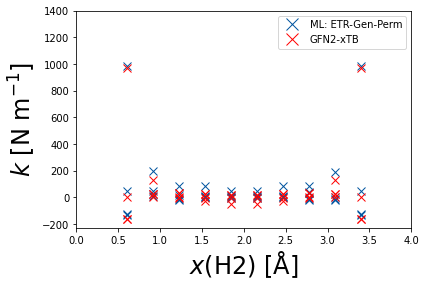

In [4]:
model = 'perm'
if model == 'indexed':
    model_nickname = 'Idx'
elif model == 'perm':
    model_nickname = 'Perm'

for test in ['absArith']:
    fc_ML_a = np.zeros(40)
    for j in range(0,len(np.genfromtxt(f'plots/H3_{test}_{model}/fc_ML_{model}_m')),90):

        fc_ML_l = []
        fc_xTB_l = []

        fc_ML = np.genfromtxt(f'plots/H3_{test}_{model}/fc_ML_{model}_m')[j:j+90]
        fc_xTB = np.genfromtxt(f'plots/H3_{test}_{model}/fc_xTB_{model}_m')[j:j+90]

        for i in range(10):

            fc_ML_temp = list(fc_ML[9*i:9*i+9])
            fc_xTB_temp = list(fc_xTB[9*i:9*i+9])

            fc_ML_temp.sort(key = abs)
            fc_xTB_temp.sort(key = abs)

            fc_ML_l.extend(fc_ML_temp[5:])
            fc_xTB_l.extend(fc_xTB_temp[5:])

        fc_ML_a += np.array(fc_ML_l)

    fc_ML_a = fc_ML_a/5


    x = list(np.linspace(0,2.8,10) + 0.6)
    x_l = []

    for j in range(10):
        for i in range(4):
            x_l.append(x[j])


    plt.plot(x_l,(np.array(fc_ML_l)/atomic_time_unit**2*atomic_mass_unit),'x',label = f'ML: ETR-Gen-{model_nickname}',markersize = 8)
    #plt.plot(x,fc_sum_ML_list,'x',label = 'ML: ETR|Idx|Multi')

    #plt.plot(x_l,fc_ML_l,'x',label = 'ML: ETR|Idx|Multi ; mean of 5 rnd_states')

    plt.xlim([0,4])
    plt.ylim([-230,1400])

#plt.plot([2.,2.],[-1500,1500],color = 'black')
plt.plot(x_l,np.array(fc_xTB_l)/atomic_time_unit**2*atomic_mass_unit,'x',label = r'GFN2-xTB',color = 'red',markersize = 8)

plt.legend(loc='upper right')#, bbox_to_anchor=(1, 0.5))
plt.xlabel(r'$x$(H2) [$\mathrm{\AA}$]',fontsize=24)
plt.ylabel(r'$k~[\mathrm{N~\mathrm{m}^{-1}}]$',fontsize=24)

sname = f'plots/H3_{test}_{model}/force_const_H3'

plt.savefig(f'{sname}.svg')
plt.savefig(f'{sname}.png')
plt.savefig(f'{sname}.eps')


a = np.genfromtxt('hess_xTB_indexed_m')

In [ ]:
var ='hess'
model = 'indexed'
for test in ['adj1','adj2','adj3']:#,'indexed']:
    model2 ='m'
    folder_name = f'plots/H3_{test}_{model}/'

    var_xTB = np.genfromtxt(f'{folder_name}{var}_xTB_{model}_{model2}')
    var_ML = np.genfromtxt(f'{folder_name}{var}_ML_{model}_{model2}')


    MSE_l = []
    for i in range(0,len(var_xTB),81):
        temp = (var_ML[i:i+81]-var_xTB[i:i+81])**2
        MSE_l.append(np.mean(temp))

    MSE_arr = np.zeros([5,10])
    l = 0
    for i in range(10):
        for j in range(5):
            MSE_arr[j,i] = MSE_l[l]
            l += 1


    x = list(np.linspace(0,2.8,10) + 0.6)

    MSE_mean = np.mean(MSE_arr,axis = 0)
    MSE_std = np.std(MSE_arr,axis = 0)

    print(MSE_mean)
    print(MSE_std)

    plt.errorbar(x,MSE_mean,yerr = MSE_std, fmt='x', label = f'{test}')

    plt.legend()

In [ ]:
MSE_dl1 = np.genfromtxt(f'plots/MSE_d_RFR1')
MSE_ndl1 = np.genfromtxt(f'plots/MSE_nd_RFR1')

MSE_dl = np.genfromtxt(f'plots/MSE_d_RFR')
MSE_ndl = np.genfromtxt(f'plots/MSE_nd_RFR')

MSE_d = np.zeros([10,10])
MSE_nd = np.zeros([10,10])
for i in range(5):
    MSE_d[i,:] = MSE_dl[10*i:10*i+10]
    MSE_nd[i,:] = MSE_ndl[10*i:10*i+10]

for i in range(5):
    MSE_d[i+5,:] = MSE_dl1[10*i:10*i+10]
    MSE_nd[i+5,:] = MSE_ndl1[10*i:10*i+10]

In [4]:
model = 'perm'
if model == 'indexed':
    model_nickname = 'Idx'
elif model == 'perm':
    model_nickname = 'Perm'

folder = 'symmetry_prop'

hess_dl = np.genfromtxt(f'plots/{folder}/hess_d_{model}_m')
hess_ndl = np.genfromtxt(f'plots/{folder}/hess_nd_{model}_m')

diff_d = []
diff_nd = []

for i in range(5):
    hess_d_t = hess_dl[i*10*27:10*27+i*10*27]
    hess_nd_t = hess_ndl[i*10*27:10*27+i*10*27]
    for j in range(5):
        hess_d_t_f = hess_d_t[(9-j)*27:27+27*(9-j)]
        hess_d_t_f[18:27] = hess_d_t[:9]
        hess_d_t_f[:9] = hess_d_t[18:27]
        diff_d.extend(hess_d_t[j*27:27+27*j]-(hess_d_t_f[(9-j)*27:27+27*(9-j)]))
        diff_nd.extend(hess_nd_t[j*27:27+27*j]-(hess_nd_t[(9-j)*27:27+27*(9-j)]))


print(diff_d[:27])
print(diff_nd[:27])



FileNotFoundError: plots/symmetry_prop/hess_d_perm_m not found.

In [12]:
MSE_dl = np.genfromtxt(f'plots/MSE_sigma/MSE_d_indexed_m_RFR')
MSE_ndl = np.genfromtxt(f'plots/MSE_sigma/MSE_nd_indexed_m_RFR')

MSE_d = np.zeros([10,10])
MSE_nd = np.zeros([10,10])
for i in range(10):
    MSE_d[i,:] = MSE_dl[10*i:10*i+10]
    MSE_nd[i,:] = MSE_ndl[10*i:10*i+10]

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


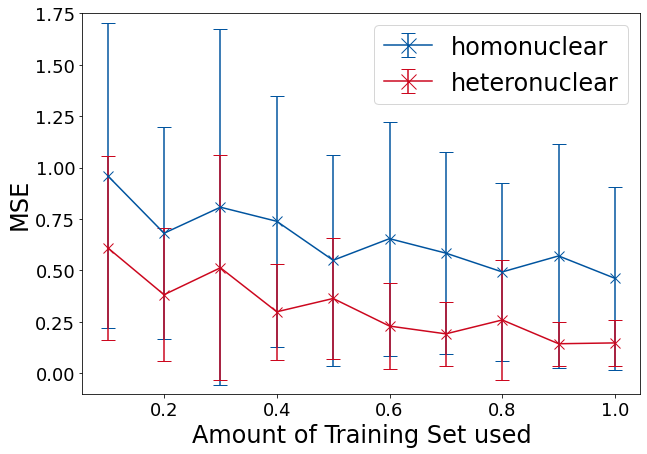

In [13]:
import matplotlib.pyplot as plt
import numpy as np

fontsize = 24
MSE_d_mean_list = []
MSE_nd_mean_list = []
std_d_l = []
std_nd_l = []
x =  [0.1 ,0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1. ]
plt.rcParams.update({'errorbar.capsize': 5})
plt.style.use('rwth_colors.mplstyle')

for k in range(10):
    std_d = np.std(MSE_d[:,k])
    std_nd = np.std(MSE_nd[:,k])

    MSE_d_mean = np.mean(MSE_d[:,k])
    MSE_nd_mean = np.mean(MSE_nd[:,k])

    MSE_d_mean_list.append(MSE_d_mean)
    MSE_nd_mean_list.append(MSE_nd_mean)
    std_d_l.append(std_d)
    std_nd_l.append(std_nd)

plt.errorbar(x,np.array(MSE_d_mean_list),yerr = std_d_l,fmt = 'x-',markersize = 10,label = 'homonuclear',capsize = 7)
plt.errorbar(0.3,10000)
plt.errorbar(x,np.array(MSE_nd_mean_list),yerr = std_nd_l,fmt = 'x-',markersize = 10,label = 'heteronuclear',capsize = 7)
plt.xlabel('Amount of Training Set used',fontsize=fontsize)
plt.ylabel('MSE',fontsize=fontsize)
plt.ylim([-0.1,1.75])
plt.legend(fontsize=fontsize)

savename = 'plots/MSE_RFR'

plt.savefig(f'{savename}.svg')
plt.savefig(f'{savename}.eps')
plt.savefig(f'{savename}.png')

plt.show()


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


[-0.02007294  0.02010821 -0.02083511  0.02283587  0.02424602 -0.02434157
 -0.02464428 -0.02474969 -0.0249539  -0.02536404 -0.02597361 -0.02609925
  0.02695075 -0.02697645  0.02734615 -0.02908357 -0.03003834  0.03022489
 -0.03055022 -0.03110828  0.0313659  -0.03144658  0.03310752  0.03360932
 -0.0337573   0.0349668  -0.03526577  0.03583491 -0.03657898 -0.03697663
 -0.03710381 -0.03756291  0.03847618  0.03890629 -0.03941331 -0.04135533
  0.04151233 -0.04349668 -0.04354966  0.04445069  0.04489887  0.04646133
 -0.04670872 -0.04940269 -0.04953842 -0.05011772 -0.05015189 -0.05085758
  0.05616322  0.0564016  -0.05680889  0.0577631  -0.0580677  -0.05823912
 -0.05961968  0.06187986 -0.06371642 -0.0692922  -0.07257582 -0.07274284
 -0.07511078  0.07530843 -0.08081155 -0.08153573 -0.08185388 -0.08275237
 -0.08383744  0.0865176   0.08944951 -0.09415189 -0.09595961  0.09771726
 -0.09877931  0.09950799 -0.10013607 -0.10139277  0.10313751 -0.10437619
  0.10704714  0.10764046  0.10809915 -0.10971255 -0

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


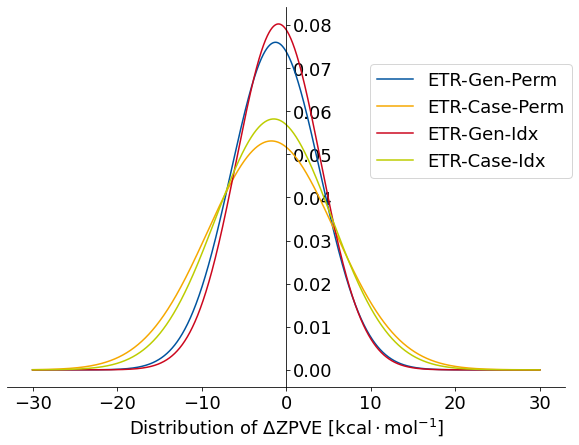

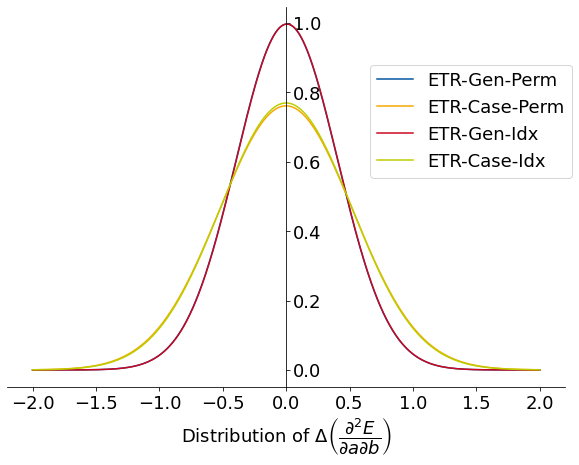

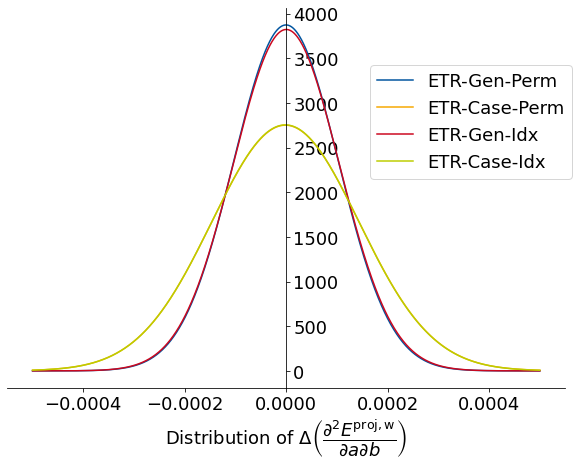

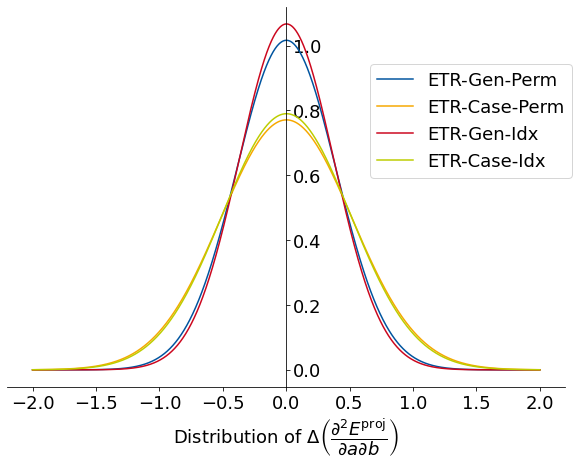

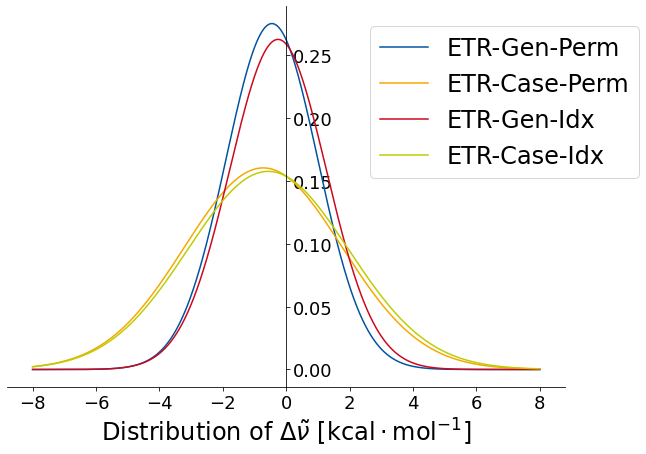

In [9]:

# hess_pm = np.genfromtxt('plots/eigv_ML_perm_m')
# hess_ps = np.genfromtxt('plots/eigv_ML_perm_s')
# hess_xyzs = np.genfromtxt('plots/eigv_ML_indexed_s')
# hess_xyzm = np.genfromtxt('plots/eigv_ML_indexed_m')
# hess_xTB_xyzs = np.genfromtxt('plots/eigv_xTB_indexed_s')
# hess_xTB_xyzm = np.genfromtxt('plots/eigv_xTB_indexed_m')
# hess_xTB_ps = np.genfromtxt('plots/eigv_xTB_perm_s')
# hess_xTB_pm = np.genfromtxt('plots/eigv_xTB_perm_m')


import matplotlib.pyplot as plt
import math
import numpy as np



# hess_pm = np.genfromtxt('plots/hess_ML_perm_m')
# hess_ps = np.genfromtxt('plots/hess_ML_perm_s')
# hess_xyzs = np.genfromtxt('plots/hess_ML_xyz_s')
# hess_xyzm = np.genfromtxt('plots/hess_ML_xyz_m')
# hess_xTB_xyzs = np.genfromtxt('plots/hess_xTB_xyz_s')
# hess_xTB_xyzm = np.genfromtxt('plots/hess_xTB_xyz_m')
# hess_xTB_ps = np.genfromtxt('plots/hess_xTB_perm_s')
# hess_xTB_pm = np.genfromtxt('plots/hess_xTB_perm_m')

# hess_pm = np.genfromtxt('plots/freq_ML_perm_m')
# hess_ps = np.genfromtxt('plots/freq_ML_perm_s')
# hess_xyzs = np.genfromtxt('plots/freq_ML_xyz_s')
# hess_xyzm = np.genfromtxt('plots/freq_ML_xyz_m')
# hess_xTB_xyzs = np.genfromtxt('plots/freq_xTB_xyz_s')
# hess_xTB_xyzm = np.genfromtxt('plots/freq_xTB_xyz_m')
# hess_xTB_ps = np.genfromtxt('plots/freq_xTB_perm_s')
# hess_xTB_pm = np.genfromtxt('plots/freq_xTB_perm_m')
folder = 'Data_8'
par = ['ZPE','hess','hess_w','hess_p','wn']
xlabel = [r'Distribution of $\Delta \mathrm{ZPVE}~[\mathrm{kcal \cdot mol^{-1}}]$',r'Distribution of $\Delta \left(\dfrac{\partial ^2 E}{\partial a \partial b}\right)$',
            r'Distribution of $\Delta \left(\dfrac{\partial ^2 E^\mathrm{proj,w}}{\partial a \partial b}\right)$',r'Distribution of $\Delta \left(\dfrac{\partial ^2 E^\mathrm{proj}}{\partial a \partial b}\right)$',
            r'Distribution of $\Delta \tilde{\nu}$ [$\mathrm{kcal \cdot mol^{-1}}$]']
limits = [[-30,30],[-2,2],[-5e-4,5e-4],[-2,2],[-8,8]]

# limits = [[-6.5e-4,6.5e-4]]
# par =  ['hess_w']
# xlabel = [r'Distribution of $\Delta \left(\dfrac{\partial ^2 H^\mathrm{proj,w}}{\partial a \partial b}\right)$']

for i in range(len(par)):
    val = f'/{folder}/{par[i]}'
    hess_pm = np.genfromtxt(f'plots/{val}_ML_perm_m')
    hess_ps = np.genfromtxt(f'plots/{val}_ML_perm_s')
    hess_xyzs = np.genfromtxt(f'plots/{val}_ML_indexed_s')
    hess_xyzm = np.genfromtxt(f'plots/{val}_ML_indexed_m')
    hess_xTB_xyzs = np.genfromtxt(f'plots/{val}_xTB_indexed_s')
    hess_xTB_xyzm = np.genfromtxt(f'plots/{val}_xTB_indexed_m')
    hess_xTB_ps = np.genfromtxt(f'plots/{val}_xTB_perm_s')
    hess_xTB_pm = np.genfromtxt(f'plots/{val}_xTB_perm_m')

    if par[i] == 'wn': 
        fontsize = 24
    else:
        fontsize = 18

    plt.style.use('rwth_colors.mplstyle')
    def f(x,SD,mean):
        pi = math.pi
        #print(pi)
        #y = np.zeros(len(x))
        y = 1.0/(SD*math.sqrt(2*pi))*np.exp(-0.5*((x-mean)/SD)**2)
        return y
    list_plot = []
    fig, ax = plt.subplots()
    ax.spines['left'].set_visible(False)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(True)
    ax.spines["right"].set_position(("data", 0))

    #ax.yaxis.set_ticks_position('right')
    #plt.tick_params(axis='y', which='both', labelleft='off', labelright='on')
    ax.yaxis.tick_right()
    #ax.yaxis.set_ticks_position('both')

    Delta_hess_pm = np.array([np.array(hess_pm),np.array(hess_xTB_pm)])
    Delta_hess_ps = np.array([np.array(hess_ps),np.array(hess_xTB_ps)])
    Delta_hess_xyzs = np.array([np.array(hess_xyzs), np.array(hess_xTB_xyzs)])
    Delta_hess_xyzm = np.array([np.array(hess_xyzm),np.array(hess_xTB_xyzm)])

    for element in [Delta_hess_pm,Delta_hess_ps,Delta_hess_xyzm,Delta_hess_xyzs]:


        if par[i] == 'ZPE':

            array_xtb = ( element[0] - element[1])*hplanck*conv_J_to_eV*23.060541945# 
            
        elif par[i] == 'wn':
            array_xtb = ( element[0] - element[1])*0.002859144166
            array_xtb =sorted(array_xtb,key=abs)
            boolfunc = True
            j = 0
            while boolfunc:
                if np.abs(array_xtb[j]) > 0.02:
                    boolfunc = False
                j+=1
            array_xtb = np.array(array_xtb[j-1:-5])

            boolfunc = True
            j = 0

            print(array_xtb[:])

            while boolfunc:
                if np.abs(array_xtb[-j]) < 10.:
                    boolfunc = False
                j+=1
            #print(array_xtb[:-j+1])
            #array_xtb = np.array(array_xtb[:-j+1])
            print(array_xtb)

        else:
            array_xtb = ( element[0] - element[1])

        MD = sum(abs(array_xtb.mean()-array_xtb)/len(array_xtb))
        
        dy2 = sum((array_xtb-array_xtb.mean())**2)
        SD = np.sqrt(dy2/len(array_xtb))
        SD = SD
        x = np.linspace(limits[i][0],limits[i][1],2000)
        #print(x)
        mean = array_xtb.mean()
        y = f(x,SD,mean)
        pl, = ax.plot(x,y)
        list_plot.append(pl)

    list_plot[0].set_label(r'ETR-Gen-Perm')
    list_plot[1].set_label(r'ETR-Case-Perm')
    
    list_plot[2].set_label(r'ETR-Gen-Idx')
    list_plot[3].set_label(r'ETR-Case-Idx')



    # plt.xlabel(r'Distribution of $\Delta \tilde{\nu}_\mathrm{n}$ [$\mathrm{cm}^{-1}$]')#[$\mathrm{cm}^{-1}$]' )
    # plt.xlabel(r'$\Delta \mathrm{ZPE}~[\mathrm{eV}]$')#\lambda \left(\dfrac{\partial ^2 H^\mathrm{proj}}{\partial a \partial b}\right)$')#$ \Delta \mathrm{ZPE} [\mathrm{eV}]$')#$\dfrac{\partial ^2 H^\mathrm{proj,w}}{\partial a \partial b}$')#\sigma^\mathrm{corr}
    if par[i] == 'wn':
        plt.xlabel(xlabel[i],fontsize = fontsize)
    else:
        plt.xlabel(xlabel[i],fontsize = fontsize)

    savename = f'plots/{folder}/error_distribution_ml_{par[i]}'

    plt.setp(ax.yaxis.get_majorticklabels(), rotation=0, ha="left")
    plt.legend(loc=(0.65,0.55),fontsize = fontsize)

    plt.savefig(f'{savename}.png')
    plt.savefig(f'{savename}.svg')
    plt.savefig(f'{savename}.eps')
    

In [ ]:
hess_pm = np.genfromtxt('plots/hess_ML_perm_m')
hess_ps = np.genfromtxt('plots/hess_ML_perm_s')
hess_xyzs = np.genfromtxt('plots/hess_ML_xyz_s')
hess_xyzm = np.genfromtxt('plots/hess_ML_xyz_m')
hess_xTB_xyzs = np.genfromtxt('plots/hess_xTB_xyz_s')
hess_xTB_xyzm = np.genfromtxt('plots/hess_xTB_xyz_m')
hess_xTB_ps = np.genfromtxt('plots/hess_xTB_perm_s')
hess_xTB_pm = np.genfromtxt('plots/hess_xTB_perm_m')

import matplotlib.pyplot as plt
import math
plt.style.use('rwth_colors.mplstyle')

def f(x,SD,mean):
    pi = math.pi
    #print(pi)
    #y = np.zeros(len(x))
    y = 1.0/(SD*math.sqrt(2*pi))*np.exp(-0.5*((x-mean)/SD)**2)
    return y

list_plot = []
fig, ax = plt.subplots()
ax.spines['left'].set_visible(False)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(True)
ax.spines["right"].set_position(("data", 0))

#ax.yaxis.set_ticks_position('right')
#plt.tick_params(axis='y', which='both', labelleft='off', labelright='on')
ax.yaxis.tick_right()
#ax.yaxis.set_ticks_position('both')
print(ax)


Delta_hess_pm = np.array([np.array(hess_pm),np.array(hess_xTB_pm)])
Delta_hess_ps = np.array([np.array(hess_ps),np.array(hess_xTB_ps)])
Delta_hess_xyzs = np.array([np.array(hess_xyzs), np.array(hess_xTB_xyzs)])
Delta_hess_xyzm = np.array([np.array(hess_xyzm),np.array(hess_xTB_xyzm)])

for element in [Delta_hess_pm,Delta_hess_ps,Delta_hess_xyzm,Delta_hess_xyzs]:

    array_xtb =  1/(1 + element[1]) * (element[0] - element[1])
    MD = sum(abs(array_xtb.mean()-array_xtb)/len(array_xtb))
    
    dy2 = sum((array_xtb-array_xtb.mean())**2)
    SD = np.sqrt(dy2/len(array_xtb))
    SD = SD
    x = np.linspace(-2.5,2.5,2000)
    print(SD)
    #print(x)
    mean = array_xtb.mean()
    print(mean)
    y = f(x,SD,mean)
    pl, = ax.plot(x,y)
    list_plot.append(pl)

list_plot[0].set_label(r'Permuted; Single')
list_plot[1].set_label(r'Permuted; Multi')
list_plot[2].set_label(r'xyz; Single')
list_plot[3].set_label(r'xyz; Multi')


plt.xlabel(r'Distribution of $\Delta \dfrac{\partial ^2 H}{\partial a \partial b}}$ [$a.u.$]' )

plt.setp( ax.yaxis.get_majorticklabels(), rotation=0, ha="left")
plt.legend(loc=(0.65,0.55),fontsize=14)
plt.savefig('plots/error_distribution_ml_scl.png')
plt.savefig('plots/error_distribution_ml_scl.svg')
plt.savefig('plots/error_distribution_ml_scl.eps')

In [ ]:

for idx in range(len(np.unique(grps_test))):

    id_0 = np.unique(grps_test)[idx]
    
    temp = (FT_diag.loc[(FT_diag['mol_idx'] == id_0)])

    mol = int(temp['molecule'].iloc[0])

    file_num = int(temp['variation'].iloc[0])

    N_atoms = N_at.iloc[mol]
    
    N_diag = int(N_atoms)

    N_non_diag = int((N_atoms ** 2 - N_atoms)/2)

    id = id_0*N_diag

    ##########

    k = int(np.where(grps_test == id_0)[0][0])

    l = int(np.where(grps_test_non_diag == id_0)[0][0])
    
    num_hess_diag = N_diag * 9
    
    num_hess_non_diag = N_non_diag * 9

    ##########
    
    file_path = glob.glob(f'tests/{molecules[mol]}/{molecules[mol]}_*/')
    inert_path_coord = f'{file_path[file_num]}'+'/inert_coord/coord.xyz'
    inert_path_hess = f'{file_path[file_num]}'+'/inert_coord/hessian'

    rot_arr = gen_rot_arr(file_path[file_num])

    hess = gen_full_hess_mat_from_vector(FT_df,hess_diag_pred[k:k+num_hess_diag],hess_non_diag_pred[l:l+num_hess_non_diag],N_atoms,mol,file_num,rot_arr)

    np.savetxt('plots/hess',hess)

    coord_inert,head = import_coord(inert_path_coord)
    hess_inert =  np.array(pd.read_csv(inert_path_hess,delimiter = '\t',index_col = 0))

    np.savetxt('plots/hess_inert',hess_inert)

    #hess_inert = import_hess(inert_path_hess,coord_inert)

    hess_inert_proj,Q = project_hess(hess_inert,coord_inert)
    hess_inert_proj_mass = mass_weighted_hessian(hess_inert_proj.copy(),coord_inert['atoms'])
    freq_inert_proj_mass = freq(hess_inert_proj_mass)

    freq_true = (freq_inert_proj_mass)
    freq_true.sort()
    list_true.extend(freq_true)

    hess_proj,Q= project_hess(hess,coord_inert)
    hess_proj_mass = mass_weighted_hessian(hess_proj.copy(),coord_inert['atoms'])
    freq_proj_mass = freq(hess_proj_mass)



    if len(freq_inert_proj_mass) != len(freq_proj_mass):
        print('Error freq not same length')


    #print(freq_inert_proj_mass)
    #print(freq_proj_mass)

    # add freq_extract(freq_proj_mass.copy()) if only non zero freq should be appended
    freq_test = (freq_proj_mass)
    freq_test.sort()
    list_test.extend(freq_test)


            #hess_inert = import_hess(inert_path_hess,coord_inert)



In [ ]:

# hess_pm = np.genfromtxt('plots/eigv_ML_perm_m')
# hess_ps = np.genfromtxt('plots/eigv_ML_perm_s')
# hess_xyzs = np.genfromtxt('plots/eigv_ML_indexed_s')
# hess_xyzm = np.genfromtxt('plots/eigv_ML_indexed_m')
# hess_xTB_xyzs = np.genfromtxt('plots/eigv_xTB_indexed_s')
# hess_xTB_xyzm = np.genfromtxt('plots/eigv_xTB_indexed_m')
# hess_xTB_ps = np.genfromtxt('plots/eigv_xTB_perm_s')
# hess_xTB_pm = np.genfromtxt('plots/eigv_xTB_perm_m')


import matplotlib.pyplot as plt
import math
import numpy as np



# hess_pm = np.genfromtxt('plots/hess_ML_perm_m')
# hess_ps = np.genfromtxt('plots/hess_ML_perm_s')
# hess_xyzs = np.genfromtxt('plots/hess_ML_xyz_s')
# hess_xyzm = np.genfromtxt('plots/hess_ML_xyz_m')
# hess_xTB_xyzs = np.genfromtxt('plots/hess_xTB_xyz_s')
# hess_xTB_xyzm = np.genfromtxt('plots/hess_xTB_xyz_m')
# hess_xTB_ps = np.genfromtxt('plots/hess_xTB_perm_s')
# hess_xTB_pm = np.genfromtxt('plots/hess_xTB_perm_m')

# hess_pm = np.genfromtxt('plots/freq_ML_perm_m')
# hess_ps = np.genfromtxt('plots/freq_ML_perm_s')
# hess_xyzs = np.genfromtxt('plots/freq_ML_xyz_s')
# hess_xyzm = np.genfromtxt('plots/freq_ML_xyz_m')
# hess_xTB_xyzs = np.genfromtxt('plots/freq_xTB_xyz_s')
# hess_xTB_xyzm = np.genfromtxt('plots/freq_xTB_xyz_m')
# hess_xTB_ps = np.genfromtxt('plots/freq_xTB_perm_s')
# hess_xTB_pm = np.genfromtxt('plots/freq_xTB_perm_m')
folder = 'Data_8'
par = ['wn']
xlabel = [r'Distribution of $\Delta \tilde{\nu}$ [$\mathrm{kcal \cdot mol^{-1}}$]']
limits = [[-30,30],[-2,2],[-5e-4,5e-4],[-2,2],[-8,8]]

# limits = [[-6.5e-4,6.5e-4]]
# par =  ['hess_w']
# xlabel = [r'Distribution of $\Delta \left(\dfrac{\partial ^2 H^\mathrm{proj,w}}{\partial a \partial b}\right)$']

for i in range(len(par)):
    val = f'/{folder}/{par[i]}'
    hess_pm = np.genfromtxt(f'plots/{val}_ML_perm_m')
    hess_ps = np.genfromtxt(f'plots/{val}_ML_perm_s')
    hess_xyzs = np.genfromtxt(f'plots/{val}_ML_indexed_s')
    hess_xyzm = np.genfromtxt(f'plots/{val}_ML_indexed_m')
    hess_xTB_xyzs = np.genfromtxt(f'plots/{val}_xTB_indexed_s')
    hess_xTB_xyzm = np.genfromtxt(f'plots/{val}_xTB_indexed_m')
    hess_xTB_ps = np.genfromtxt(f'plots/{val}_xTB_perm_s')
    hess_xTB_pm = np.genfromtxt(f'plots/{val}_xTB_perm_m')

    plt.style.use('rwth_colors.mplstyle')

    list_plot = []
    fig, ax = plt.subplots()
    ax.spines['left'].set_visible(False)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(True)
    ax.spines["right"].set_position(("data", 0))

    #ax.yaxis.set_ticks_position('right')
    #plt.tick_params(axis='y', which='both', labelleft='off', labelright='on')
    ax.yaxis.tick_right()
    #ax.yaxis.set_ticks_position('both')
    print(ax)


    Delta_hess_pm = np.array([np.array(hess_pm),np.array(hess_xTB_pm)])
    Delta_hess_ps = np.array([np.array(hess_ps),np.array(hess_xTB_ps)])
    Delta_hess_xyzs = np.array([np.array(hess_xyzs), np.array(hess_xTB_xyzs)])
    Delta_hess_xyzm = np.array([np.array(hess_xyzm),np.array(hess_xTB_xyzm)])

    for element in [Delta_hess_pm,Delta_hess_ps,Delta_hess_xyzm,Delta_hess_xyzs]:


        if par[i] == 'ZPE':

            array_xtb = ( element[0] - element[1])*hplanck*conv_J_to_eV*23.060541945# 
            
        elif par[i] == 'wn':
            array_xtb = ( element[0] - element[1])*0.002859144166
            array_xtb =sorted(array_xtb,key=abs)
            boolfunc = True
            j = 0
            while boolfunc:
                if np.abs(array_xtb[j]) > 0.25:
                    boolfunc = False
                j+=1
            array_xtb = array_xtb[j-1:]

        else:
            array_xtb = ( element[0] - element[1])

        pl = ax.hist(array_xtb,bins=np.linspace(-40,40,320))
        list_plot.append(pl)

    #list_plot[0].set_label(r'ETR-Gen-Perm')
    #list_plot[1].set_label(r'ETR-Case-Perm')
    
    #list_plot[2].set_label(r'ETR-Gen-Idx')
    #list_plot[3].set_label(r'ETR-Case-Idx')



    # plt.xlabel(r'Distribution of $\Delta \tilde{\nu}_\mathrm{n}$ [$\mathrm{cm}^{-1}$]')#[$\mathrm{cm}^{-1}$]' )
    # plt.xlabel(r'$\Delta \mathrm{ZPE}~[\mathrm{eV}]$')#\lambda \left(\dfrac{\partial ^2 H^\mathrm{proj}}{\partial a \partial b}\right)$')#$ \Delta \mathrm{ZPE} [\mathrm{eV}]$')#$\dfrac{\partial ^2 H^\mathrm{proj,w}}{\partial a \partial b}$')#\sigma^\mathrm{corr}
    if par[i] == 'ZPE':
        plt.xlabel(xlabel[i])
    else:
        plt.xlabel(xlabel[i],fontsize =24)

    savename = f'plots/{folder}/error_hist_{par[i]}'

    plt.setp(ax.yaxis.get_majorticklabels(), rotation=0, ha="left")
    plt.legend(loc=(0.65,0.55),fontsize=14)
    #plt.ylim([0,80])
    plt.savefig(f'{savename}.png')
    plt.savefig(f'{savename}.svg')
    plt.savefig(f'{savename}.eps')
    

In [29]:
print(FT_df.iloc[:,61+11])

0       0.000000e+00
1       0.000000e+00
2       0.000000e+00
3       0.000000e+00
4       0.000000e+00
            ...     
4891    7.694097e-07
4892    7.694097e-07
4893    7.694097e-07
4894    7.694097e-07
4895    7.694097e-07
Name: E_ies_ixc_Prod, Length: 4896, dtype: float64


35
[33, 7, 9, 6, 23, 21, 23, 21, 32]
[33, 7, 9, 6, 23, 21, 23, 21, 32]
$\epsilon_\mathrm{HOAO}^\mathrm{ext}$
$\mu_A^{y,\mathrm{ext}}$
$\mu_{A,p}^{x,\mathrm{ext}}$
$\mu_A^{x,\mathrm{ext}}$
$E_\mathrm{rep}$
$\epsilon_\mathrm{HOAO}$
$E_\mathrm{rep}$
$\epsilon_\mathrm{HOAO}$
$E_\mathrm{gap}^\mathrm{ext}$
[0, 1, 2, 3, 4, 5, 6, 7, 8]
[0.4235682777894905, 0.5552685636057922, 0.6600695175044756, 0.5552685636057922, 0.8476605535730022, 0.5609487594941228, 0.547663838619887, 0.5609487594941228, 0.7939234187827474]


/home/gfeldmann/Venv/venv_hessian_ml/lib/python3.8/site-packages/sklearn/feature_selection/_univariate_selection.py:289: RuntimeWarning: invalid value encountered in true_divide
  correlation_coefficient /= X_norms
/home/gfeldmann/Venv/venv_hessian_ml/lib/python3.8/site-packages/sklearn/feature_selection/_univariate_selection.py:289: RuntimeWarning: invalid value encountered in true_divide
  correlation_coefficient /= X_norms
/home/gfeldmann/Venv/venv_hessian_ml/lib/python3.8/site-packages/sklearn/feature_selection/_univariate_selection.py:289: RuntimeWarning: invalid value encountered in true_divide
  correlation_coefficient /= X_norms
/home/gfeldmann/Venv/venv_hessian_ml/lib/python3.8/site-packages/sklearn/feature_selection/_univariate_selection.py:289: RuntimeWarning: invalid value encountered in true_divide
  correlation_coefficient /= X_norms
/home/gfeldmann/Venv/venv_hessian_ml/lib/python3.8/site-packages/sklearn/feature_selection/_univariate_selection.py:289: RuntimeWarning: inv

[68, 9, 43, 83, 57, 91, 6, 23, 61]
[34, 9, 9, 15, 23, 23, 6, 23, 27]
$\epsilon_\mathrm{LUAO}^\mathrm{ext}$
$\mu_{A,p}^{x,\mathrm{ext}}$
$\mu_{A,p}^{x,\mathrm{ext}}$
$\theta_x^\mathrm{ext}$
$E_\mathrm{rep}$
$E_\mathrm{rep}$
$\mu_A^{x,\mathrm{ext}}$
$E_\mathrm{rep}$
$E_\mathrm{IES+IXC}$
[0, 1, 2, 3, 4, 5, 6, 7, 8]
[0.8046680457153075, 0.315473151507222, 0.11520167368881477, 0.08088516074291638, 0.8887180563600029, 0.4468474990419947, 0.5641075482756844, 0.47558246534281634, 0.5437866386165481]


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


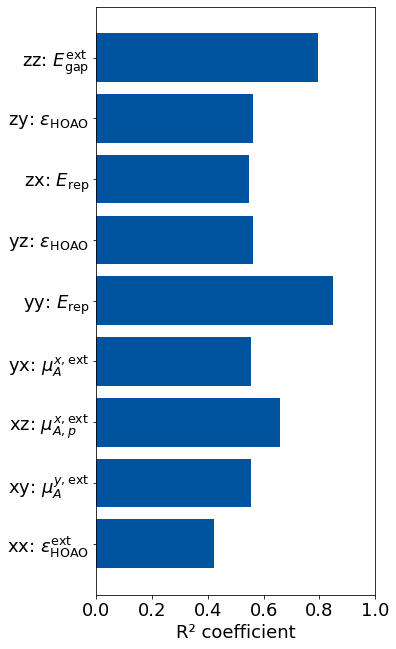

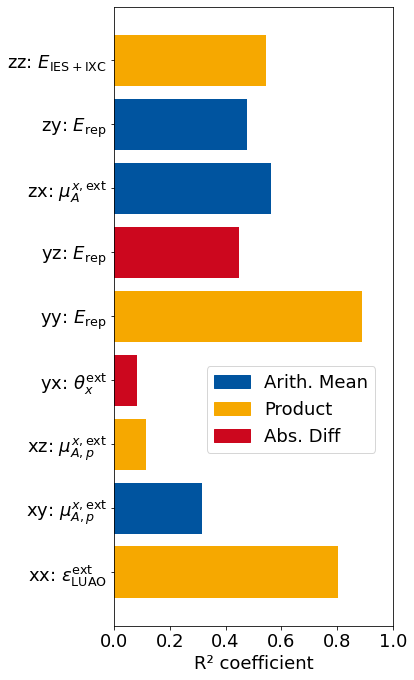

In [8]:

import matplotlib.patches as mpatches
import matplotlib.colors
fontsize = 18
color_map = matplotlib.colors.get_named_colors_mapping()
color_map["blue"] = "#00549F"
color_map["red"] = "#F6A800"
color_map["yellow"] = "#CC071E"
col_name_nd = [ r'$R_{AB}$', r'$CN_A$', r'$CN_A^\mathrm{ext}$', r'$\mu_A^x$', r'$\mu_A^y$', r'$\mu_A^z$', r'$\mu_A^{x,\mathrm{ext}}$', r'$\mu_A^{y,\mathrm{ext}}$', r'$\mu_A^{z,\mathrm{ext}}$',
r'$\mu_{A,p}^{x,\mathrm{ext}}$', r'$\mu_{A,p}^{y,\mathrm{ext}}$', r'$\mu_{A,p}^{z,\mathrm{ext}}$',
r'$\theta_x$', r'$\theta_y$', r'$\theta_z$', r'$\theta_x^\mathrm{ext}$', r'$\theta_y^\mathrm{ext}$', r'$\theta_z^\mathrm{ext}$',
r'$E_\mathrm{resp}$', r'$E_\mathrm{gap}$', r'$\mu_\mathrm{chem}$', r'$\epsilon_\mathrm{HOAO}$', r'$\epsilon_\mathrm{LUAO}$', r'$E_\mathrm{rep}$', r'$E_\mathrm{EHT}$',
r'$E_\mathrm{disp}^{(2)}$', r'$E_\mathrm{disp}^{(3)}$', r'$E_\mathrm{IES+IXC}$', r'$E_\mathrm{AES}$',
 r'$E_\mathrm{tot}$', r'$E_\mathrm{AXC}$', r'$\mu_\mathrm{chem}^\mathrm{ext}$', r'$E_\mathrm{gap}^\mathrm{ext}$', r'$\epsilon_\mathrm{HOAO}^\mathrm{ext}$', r'$\epsilon_\mathrm{LUAO}^\mathrm{ext}$']
print(len(col_name_nd))
#r'$x_i$', r'$y_i$', r'$z_i$',
elements = ['xx','xy','xz','yx','yy','yz','zx','zy','zz']
for j in ['diag','nondiag']:
    list_list = []
    idx_list = []
    r_list = []
    for i in elements:
        target = np.array(FT_df.loc[(FT_df['y_idx'] == i)& (FT_df['block'] == j)]['y'])
        if j == 'diag':
            feature = np.array(FT_df.loc[(FT_df['y_idx'] == i)& (FT_df['block'] == j)])[:,9:46]
        elif j == 'nondiag':
            feature = np.array(FT_df.loc[(FT_df['y_idx'] == i)& (FT_df['block'] == j)])[:,9:]

        r = r_regression(feature,target)
        r_max_idx =np.nanargmax(np.array(r))
        #print(i)
        #print(r[r_max_idx]**2)
        #print(FT_df.loc[(FT_df['y_idx'] == i)& (FT_df['block'] == j)].iloc[:,12+np.nanargmax(np.array(r))].name)
        idx_list.append(r_max_idx)
        r_list.append(r[r_max_idx])

    print(idx_list)

    for i in range(len(idx_list)):
        if idx_list[i]>len(col_name_nd) and idx_list[i]<2*len(col_name_nd)-1:
            idx_list[i] = idx_list[i]- (len(col_name_nd)-1) 
            list_list.append(2)

        elif idx_list[i]>2*len(col_name_nd)-1 and idx_list[i]<3*len(col_name_nd)-1:
            idx_list[i] = idx_list[i]- 2*(len(col_name_nd)-1) 
            list_list.append(3)

        else:
            list_list.append(1)

    print(idx_list)

    for i in range(len(idx_list)):
        print(col_name_nd[idx_list[i]])

    ticks = []
    for i in range(len(r_list)):
        ticks.append(i)

    print(ticks)
    print(r_list)
    col_name_10 =[]
    for i in range(len(idx_list)):
        col_name_10.append(f'{elements[i]}: {col_name_nd[idx_list[i]]}')

    fig,ax = plt.subplots()
    color = ['blue','red','yellow']

    for i in range(len(r_list)):
        ax.barh(ticks[i],r_list[i],color=color[list_list[i]-1])
        
    ax.set_yticks(ticks)
    ax.set_yticklabels(col_name_10)

    blue_patch = mpatches.Patch(color='blue', label='Arith. Mean')
    red_patch = mpatches.Patch(color='red', label='Product')
    yellow_patch = mpatches.Patch(color='yellow', label='Abs. Diff')

    if j == 'nondiag':
        ax.legend(handles=[blue_patch,red_patch,yellow_patch],fontsize=fontsize, loc='lower left', bbox_to_anchor = (0.3,0.265))

    if j =='diag':
        fig.set_figheight(19)
    else:
        fig.set_figheight(20)

    fig.set_figwidth(5)
    plt.gcf().subplots_adjust(bottom=0.45)
    plt.xlim([0,1])

    ax.set_xlabel('R² coefficient',fontsize=fontsize)

    save_name = f'Bericht/PearsonCorrelationCoeffiecient/PCC_element_specific_{j}_perm'
    plt.savefig(f'{save_name}.svg')
    plt.savefig(f'{save_name}.eps')
    plt.savefig(f'{save_name}.png')